# Global Country Analysis Using Python*.

The project covers:
- Data loading and inspection
- Data cleaning and quality checks
- Exploratory data analysis (EDA)
- Statistical analysis
- Correlation analysis
- Data visualization
- Extracting useful insights

**Dataset:** Countries of the World 2023  
**Records:** 195 countries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Dataset

Load the CSV file into a Pandas DataFrame so that it can be inspected, cleaned, and analyzed.

In [23]:
df = pd.read_csv("world-data-2023-selected-columns.csv")

## 2. Initial Data Inspection

Inspect the first few rows to understand the structure and type of information stored in the dataset.

In [24]:
df.head()

,Country,Density(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions
0,Afghanistan,NaN,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672"
1,Albania,NaN,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536"
2,Algeria,NaN,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006"
3,Andorra,NaN,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469
4,Angola,NaN,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693"


In [25]:
df.shape

(195, 10)

In [26]:
df.columns

Index(['Country', 'Density(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                195 non-null    object 
 1   Density(P/Km2)         0 non-null      float64
 2   Abbreviation           188 non-null    object 
 3   Agricultural Land( %)  188 non-null    object 
 4   Land Area(Km2)         194 non-null    object 
 5   Armed Forces size      171 non-null    object 
 6   Birth Rate             189 non-null    float64
 7   Calling Code           194 non-null    float64
 8   Capital/Major City     192 non-null    object 
 9   Co2-Emissions          188 non-null    object 
dtypes: float64(3), object(7)
memory usage: 15.4+ KB


## 3. Check for Missing Values

Before analysis, identify columns containing missing values. Missing data can affect calculations and visualizations.

In [28]:
df.isnull().sum()

Country                    0
Density(P/Km2)           195
Abbreviation               7
Agricultural Land( %)      7
Land Area(Km2)             1
Armed Forces size         24
Birth Rate                 6
Calling Code               1
Capital/Major City         3
Co2-Emissions              7
dtype: int64

## 4. Remove the Completely Empty Column

`Density(P/Km2)` contains no usable values, so it is removed from the dataset.

**Why?** A completely empty column cannot contribute to the analysis.

In [29]:
df.drop(columns=['Density(P/Km2)'], inplace=True)

In [30]:
df.shape

(195, 9)

In [10]:
df.drop(columns=['Density(P/Km2)'], inplace=True)

In [11]:
df.shape

(195, 9)

## 5. Check and Correct Data Types

Some numerical columns are stored as text because they contain characters such as commas and `%`.

These columns must be converted to numeric types before performing mathematical calculations.

In [31]:
df.dtypes

Country                   object
Abbreviation              object
Agricultural Land( %)     object
Land Area(Km2)            object
Armed Forces size         object
Birth Rate               float64
Calling Code             float64
Capital/Major City        object
Co2-Emissions             object
dtype: object

### Clean Numeric Columns

Remove formatting characters such as `%` and commas, then convert the values to numeric data.

`errors='coerce'` converts values that cannot be interpreted as numbers into `NaN`, which can then be handled as missing values.

In [37]:
df['Agricultural Land( %)'] = pd.to_numeric(
    df['Agricultural Land( %)'].astype('string').str.replace('%', '', regex=False),
    errors='coerce'
)

df['Land Area(Km2)'] = pd.to_numeric(
    df['Land Area(Km2)'].astype('string').str.replace(',', '', regex=False),
    errors='coerce'
)

df['Armed Forces size'] = pd.to_numeric(
    df['Armed Forces size'].astype('string').str.replace(',', '', regex=False),
    errors='coerce'
)

df['Co2-Emissions'] = pd.to_numeric(
    df['Co2-Emissions'].astype('string').str.replace(',', '', regex=False),
    errors='coerce'
)

In [38]:
df.dtypes

Country                   object
Abbreviation              object
Agricultural Land( %)    Float64
Land Area(Km2)           Float64
Armed Forces size        Float64
Birth Rate               float64
Calling Code             float64
Capital/Major City        object
Co2-Emissions            Float64
dtype: object

## 6. Handle Missing Values

After converting the columns to numeric types, check the missing values again.

For this project:
- **Numerical columns:** missing values are filled using the median.
- **Text columns:** missing values are filled using the mode.

In [39]:
df.isnull().sum()

Country                   0
Abbreviation              7
Agricultural Land( %)     7
Land Area(Km2)            1
Armed Forces size        24
Birth Rate                6
Calling Code              1
Capital/Major City        3
Co2-Emissions             7
dtype: int64

In [40]:
df.describe()

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions
count,188.0,194.0,171.0,189.000000,194.000000,188.0
mean,39.117553,689624.365979,159274.853801,20.214974,360.546392,177799.239362
std,21.783052,1921609.22888,380628.799271,9.945774,323.236419,838790.268386
min,0.6,0.0,0.0,5.900000,1.000000,11.0
25%,21.7,23828.25,11000.0,11.300000,82.500000,2304.25
50%,39.6,119511.0,31000.0,17.950000,255.500000,12303.0
75%,55.375,524256.0,142000.0,28.750000,506.750000,63884.25
max,82.6,17098240.0,3031000.0,46.080000,1876.000000,9893038.0


In [41]:
numeric_columns = [
    'Agricultural Land( %)',
    'Land Area(Km2)',
    'Armed Forces size',
    'Birth Rate',
    'Calling Code',
    'Co2-Emissions'
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [42]:
text_columns = [
    'Abbreviation',
    'Capital/Major City'
]

for column in text_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [43]:
df.isnull().sum()

Country                  0
Abbreviation             0
Agricultural Land( %)    0
Land Area(Km2)           0
Armed Forces size        0
Birth Rate               0
Calling Code             0
Capital/Major City       0
Co2-Emissions            0
dtype: int64

## 7. Check for Duplicate Records

Check for duplicate country names and completely duplicated rows.

Duplicate records can lead to incorrect counts, averages, and other analysis results.

In [44]:
df['Country'].duplicated().sum()

0

In [45]:
df.duplicated().sum()

0

## 8. Descriptive Statistics and Data Quality

Use descriptive statistics to understand the range, center, and spread of the numerical variables.

Also check whether the dataset contains suspicious values, such as negative values where they would not make sense.

In [46]:
df.describe()

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions
count,195.0,195.0,195.0,195.000000,195.000000,195.0
mean,39.134872,686700.707692,143487.179487,20.145282,360.007692,171858.348718
std,21.386637,1917085.00521,358803.931741,9.798615,322.490008,824096.709658
min,0.6,0.0,0.0,5.900000,1.000000,11.0
25%,22.65,24456.5,12500.0,11.450000,83.000000,2625.5
50%,39.6,119511.0,31000.0,17.950000,255.500000,12303.0
75%,54.85,520544.0,123000.0,28.445000,506.500000,61941.0
max,82.6,17098240.0,3031000.0,46.080000,1876.000000,9893038.0


In [48]:
df[['Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size',
    'Birth Rate', 'Calling Code', 'Co2-Emissions']].min()

Agricultural Land( %)     0.6
Land Area(Km2)            0.0
Armed Forces size         0.0
Birth Rate                5.9
Calling Code              1.0
Co2-Emissions            11.0
dtype: Float64

# Exploratory Data Analysis (EDA)

Now that the dataset has been cleaned, begin exploring the main country-level indicators through rankings and visualizations.

In [50]:
top_10_land = df.nlargest(10, 'Land Area(Km2)')
top_10_land[['Country', 'Land Area(Km2)']]

,Country,Land Area(Km2)
143,Russia,17098240.0
32,Canada,9984670.0
186,United States,9833517.0
36,China,9596960.0
23,Brazil,8515770.0
8,Australia,7741220.0
77,India,3287263.0
6,Argentina,2780400.0
87,Kazakhstan,2724900.0
2,Algeria,2381741.0


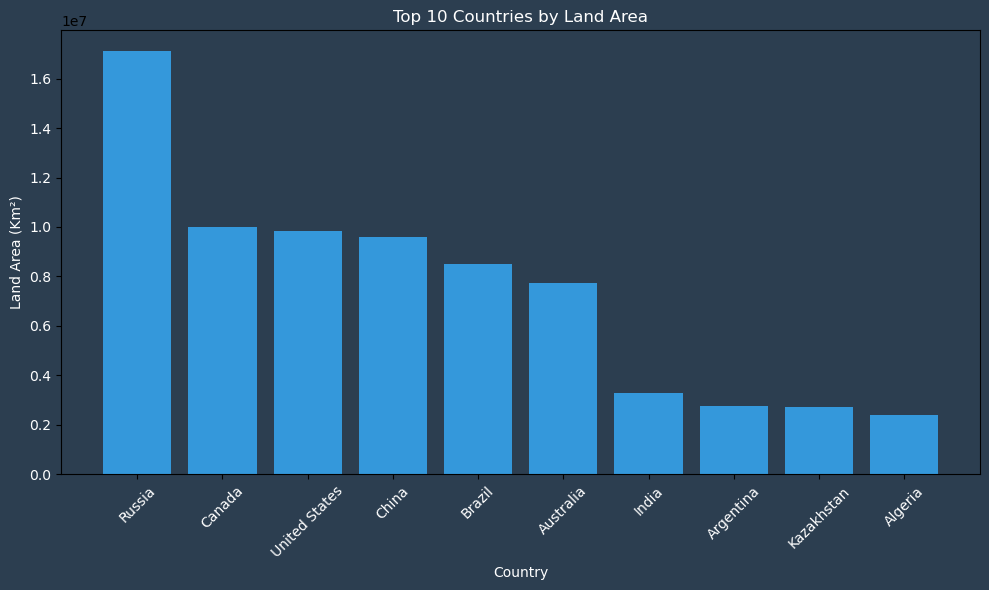

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_land['Country'],
    top_10_land['Land Area(Km2)'],
    color='#3498DB'
)

plt.title('Top 10 Countries by Land Area', color='#FFFFFF')
plt.xlabel('Country', color='#FFFFFF')
plt.ylabel('Land Area (Km²)', color='#FFFFFF')

plt.xticks(rotation=45, color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

In [54]:
top_10_co2 = df.nlargest(10, 'Co2-Emissions')

top_10_co2[['Country', 'Co2-Emissions']]

,Country,Co2-Emissions
36,China,9893038.0
186,United States,5006302.0
77,India,2407672.0
143,Russia,1732027.0
85,Japan,1135886.0
64,Germany,727973.0
79,Iran,661710.0
162,South Korea,620302.0
151,Saudi Arabia,563449.0
78,Indonesia,563325.0


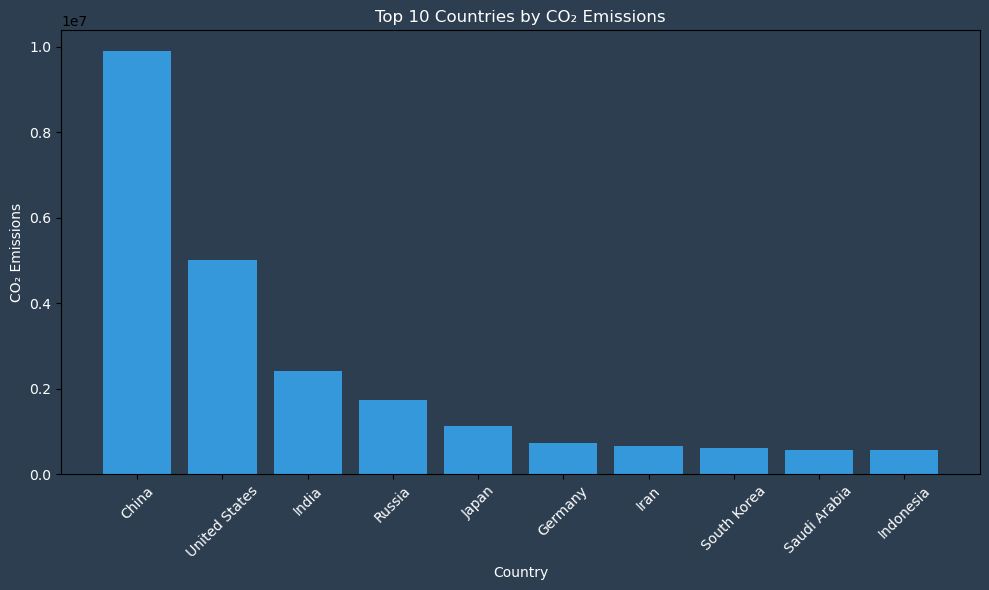

In [55]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_co2['Country'],
    top_10_co2['Co2-Emissions'],
    color='#3498DB'
)

plt.title('Top 10 Countries by CO₂ Emissions', color='#FFFFFF')
plt.xlabel('Country', color='#FFFFFF')
plt.ylabel('CO₂ Emissions', color='#FFFFFF')

plt.xticks(rotation=45, color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

In [56]:
top_10_birth = df.nlargest(10, 'Birth Rate')

top_10_birth[['Country', 'Birth Rate']]

,Country,Birth Rate
125,Niger,46.08
34,Chad,42.17
160,Somalia,41.75
105,Mali,41.54
45,Democratic Republic of the Congo,41.18
4,Angola,40.73
27,Burundi,39.01
62,The Gambia,38.54
182,Uganda,38.14
26,Burkina Faso,37.93


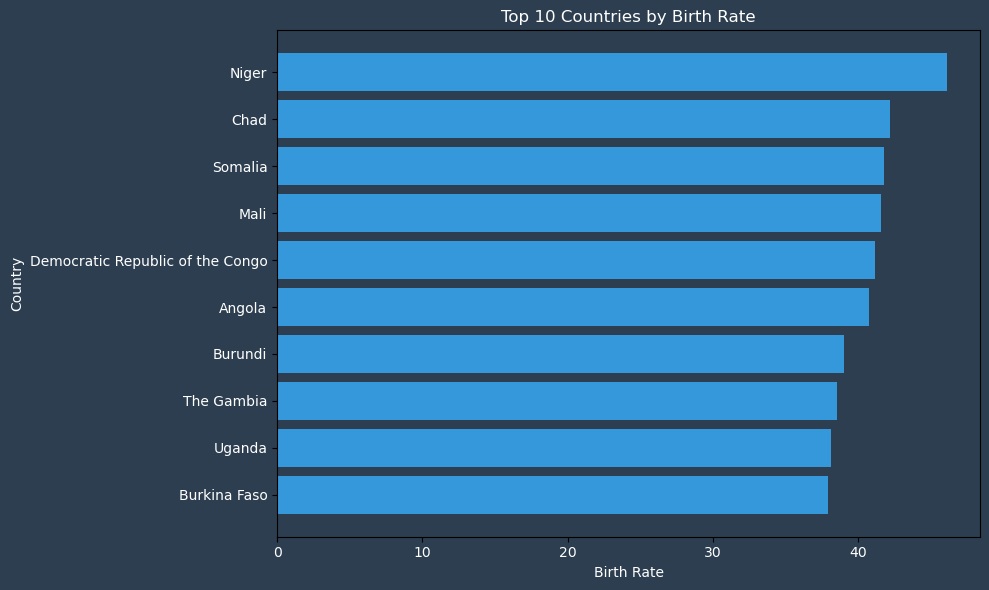

In [61]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_birth['Country'][::-1],
    top_10_birth['Birth Rate'][::-1],
    color='#3498DB'
)

plt.title('Top 10 Countries by Birth Rate', color='#FFFFFF')
plt.xlabel('Birth Rate', color='#FFFFFF')
plt.ylabel('Country', color='#FFFFFF')

plt.xticks(color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

In [58]:
top_10_military = df.nlargest(10, 'Armed Forces size')

top_10_military[['Country', 'Armed Forces size']]

,Country,Armed Forces size
77,India,3031000.0
36,China,2695000.0
127,North Korea,1469000.0
143,Russia,1454000.0
186,United States,1359000.0
131,Pakistan,936000.0
51,Egypt,836000.0
23,Brazil,730000.0
78,Indonesia,676000.0
162,South Korea,634000.0


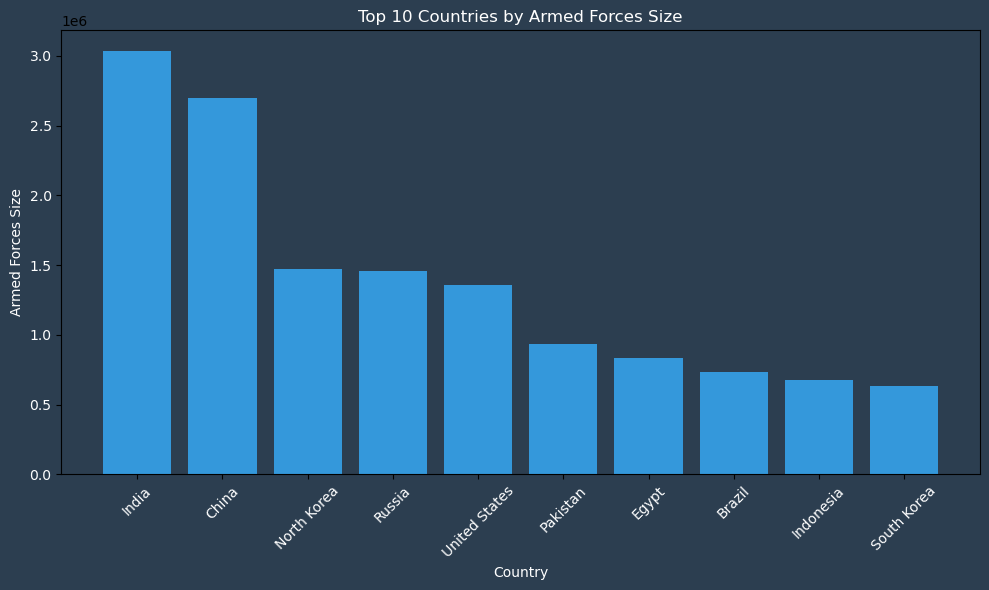

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_military['Country'],
    top_10_military['Armed Forces size'],
    color='#3498DB'
)

plt.title('Top 10 Countries by Armed Forces Size', color='#FFFFFF')
plt.xlabel('Country', color='#FFFFFF')
plt.ylabel('Armed Forces Size', color='#FFFFFF')

plt.xticks(rotation=45, color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

Correlation measures the strength and direction of a **linear relationship** between numerical variables.

- Positive value → variables tend to increase together
- Negative value → one tends to increase as the other decreases
- Value near 0 → weak linear relationship

**Important:** Correlation does not prove causation.

`Calling Code` is an identifier, so it should not be interpreted as a meaningful analytical relationship.

In [63]:
correlation = df[
    ['Agricultural Land( %)',
     'Land Area(Km2)',
     'Armed Forces size',
     'Birth Rate',
     'Calling Code',
     'Co2-Emissions']
].corr()

correlation

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions
Agricultural Land( %),1.000000,-0.031372,0.040478,0.195054,-0.066760,0.061898
Land Area(Km2),-0.031372,1.000000,0.558671,-0.063630,-0.230260,0.591510
Armed Forces size,0.040478,0.558671,1.000000,-0.129806,-0.182490,0.742572
Birth Rate,0.195054,-0.063630,-0.129806,1.000000,0.069782,-0.149560
Calling Code,-0.066760,-0.230260,-0.182490,0.069782,1.000000,-0.156016
Co2-Emissions,0.061898,0.591510,0.742572,-0.149560,-0.156016,1.000000


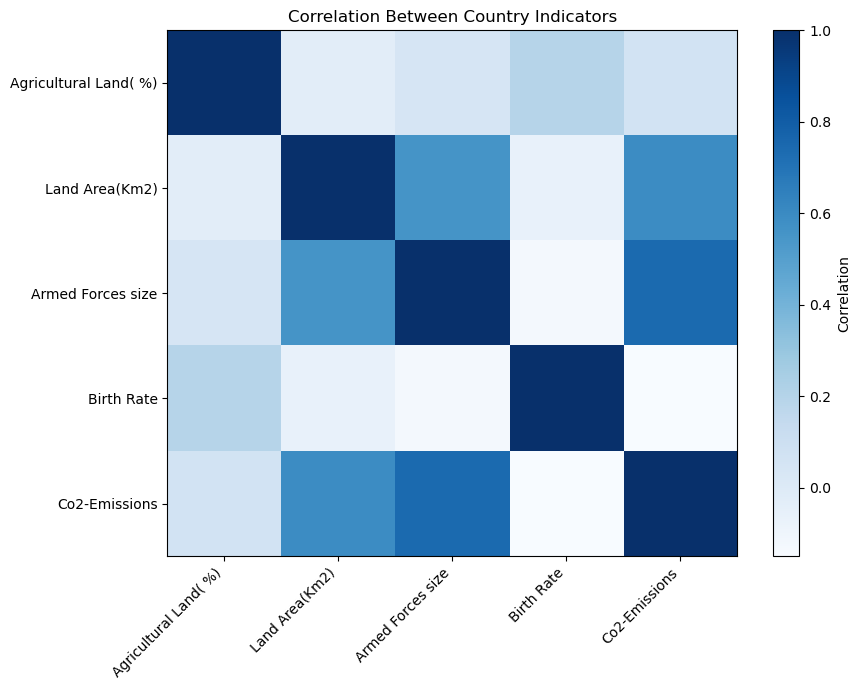

In [65]:
corr = df[
    ['Agricultural Land( %)',
     'Land Area(Km2)',
     'Armed Forces size',
     'Birth Rate',
     'Co2-Emissions']
].corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr, cmap='Blues', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Between Country Indicators')

plt.tight_layout()
plt.show()

## 10. Relationship Analysis: Land Area vs CO₂ Emissions

Use a scatter plot to visually examine whether larger land areas tend to be associated with higher CO₂ emissions in this dataset.

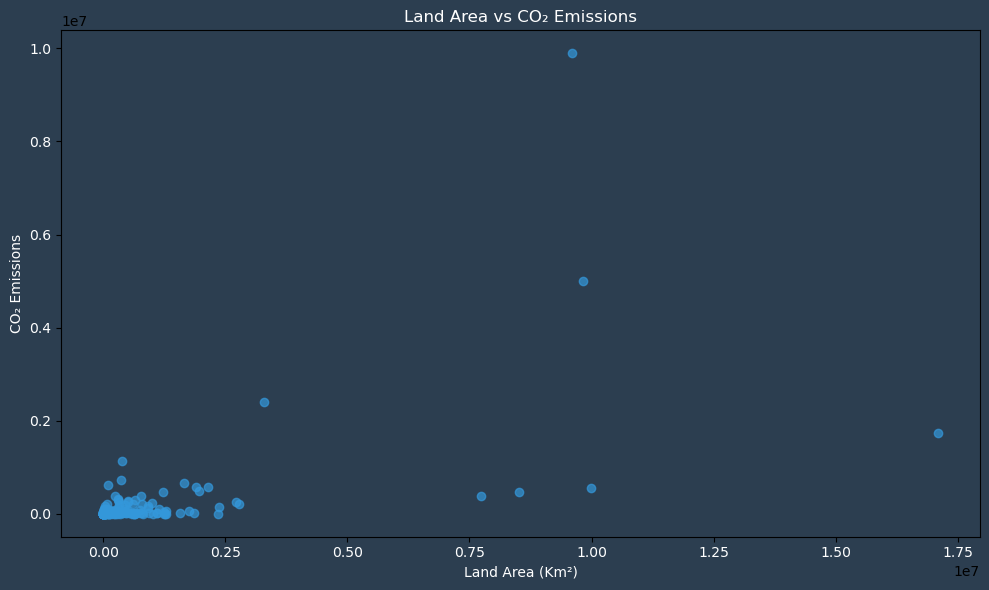

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Land Area(Km2)'],
    df['Co2-Emissions'],
    color='#3498DB',
    alpha=0.7
)

plt.title('Land Area vs CO₂ Emissions', color='#FFFFFF')
plt.xlabel('Land Area (Km²)', color='#FFFFFF')
plt.ylabel('CO₂ Emissions', color='#FFFFFF')

plt.xticks(color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

## 11. Birth Rate Statistics with NumPy

Use NumPy to calculate basic statistics such as mean, median, minimum, and maximum for birth rate.

In [67]:
mean_birth = np.mean(df['Birth Rate'])
median_birth = np.median(df['Birth Rate'])
min_birth = np.min(df['Birth Rate'])
max_birth = np.max(df['Birth Rate'])

print("Mean Birth Rate:", mean_birth)
print("Median Birth Rate:", median_birth)
print("Minimum Birth Rate:", min_birth)
print("Maximum Birth Rate:", max_birth)

Mean Birth Rate: 20.145282051282052
Median Birth Rate: 17.95
Minimum Birth Rate: 5.9
Maximum Birth Rate: 46.08


## 12. CO₂ Statistics with NumPy

Calculate basic CO₂ statistics.

Because CO₂ values vary greatly between countries, compare the **mean and median** to understand the distribution.

In [68]:
mean_co2 = np.mean(df['Co2-Emissions'])
median_co2 = np.median(df['Co2-Emissions'])
min_co2 = np.min(df['Co2-Emissions'])
max_co2 = np.max(df['Co2-Emissions'])

print("Mean CO₂ Emissions:", mean_co2)
print("Median CO₂ Emissions:", median_co2)
print("Minimum CO₂ Emissions:", min_co2)
print("Maximum CO₂ Emissions:", max_co2)

Mean CO₂ Emissions: 171858.3487179487
Median CO₂ Emissions: 12303.0
Minimum CO₂ Emissions: 11.0
Maximum CO₂ Emissions: 9893038.0


### Log Transformation for CO₂

The CO₂ distribution is highly right-skewed because a small number of countries have very large values.

A log transformation makes the distribution easier to visualize:

`log10(value)` compresses very large values while preserving their relative order.

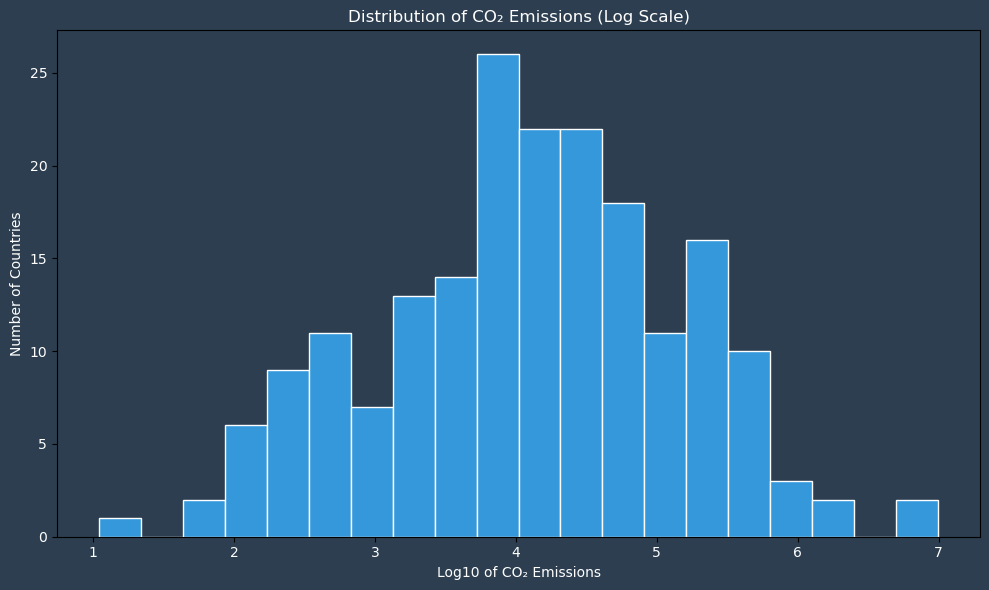

In [70]:
co2_log = np.log10(df['Co2-Emissions'])

plt.figure(figsize=(10, 6))

plt.hist(
    co2_log,
    bins=20,
    color='#3498DB',
    edgecolor='white'
)

plt.title('Distribution of CO₂ Emissions (Log Scale)', color='#FFFFFF')
plt.xlabel('Log10 of CO₂ Emissions', color='#FFFFFF')
plt.ylabel('Number of Countries', color='#FFFFFF')

plt.xticks(color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

## 13. Agricultural Land Analysis

Identify and visualize the countries with the highest percentage of agricultural land.

In [73]:
top_10_agri = df.nlargest(10, 'Agricultural Land( %)')

top_10_agri[['Country', 'Agricultural Land( %)']]

,Country,Agricultural Land( %)
187,Uruguay,82.6
151,Saudi Arabia,80.8
87,Kazakhstan,80.4
161,South Africa,79.8
27,Burundi,79.2
126,Nigeria,77.7
95,Lesotho,77.6
52,El Salvador,76.4
170,Syria,75.8
54,Eritrea,75.2


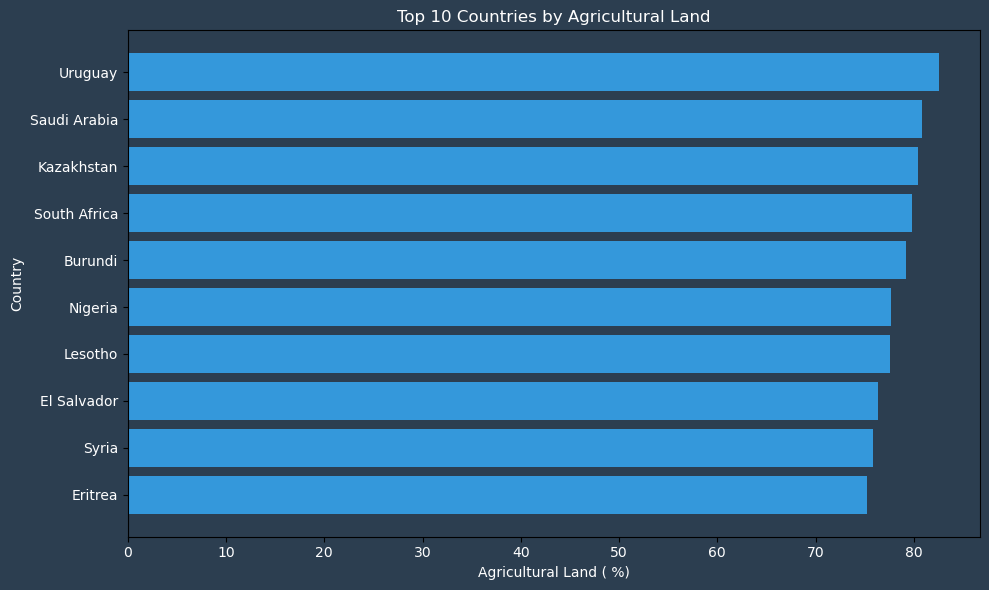

In [74]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_agri['Country'][::-1],
    top_10_agri['Agricultural Land( %)'][::-1],
    color='#3498DB'
)

plt.title('Top 10 Countries by Agricultural Land', color='#FFFFFF')
plt.xlabel('Agricultural Land ( %)', color='#FFFFFF')
plt.ylabel('Country', color='#FFFFFF')

plt.xticks(color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

## 14. Relationship Analysis: Armed Forces vs CO₂ Emissions

Use a scatter plot to examine the relationship between armed forces size and CO₂ emissions.

A visible relationship does not mean that one variable causes the other.

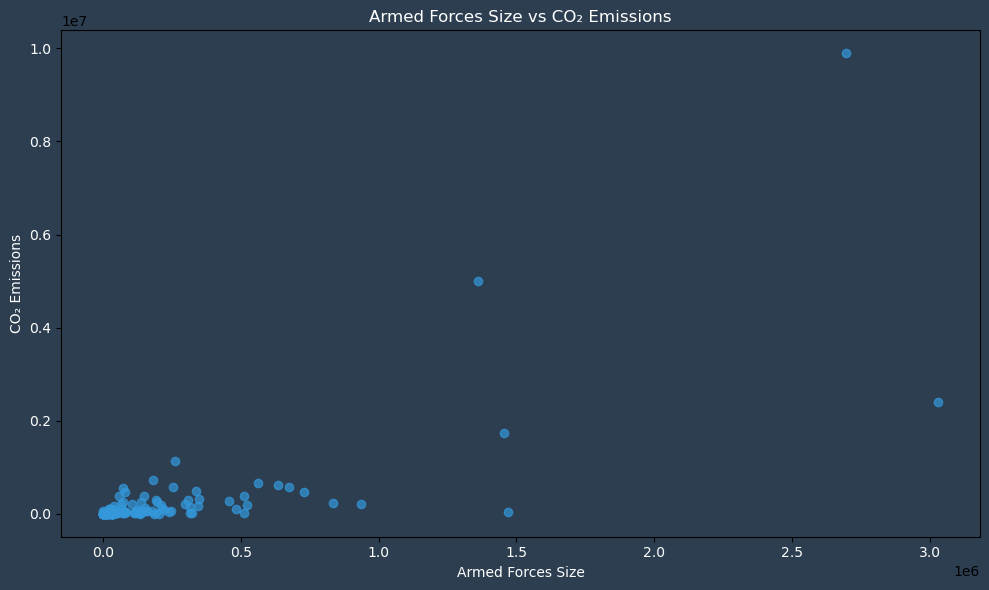

In [75]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Armed Forces size'],
    df['Co2-Emissions'],
    color='#3498DB',
    alpha=0.7
)

plt.title('Armed Forces Size vs CO₂ Emissions', color='#FFFFFF')
plt.xlabel('Armed Forces Size', color='#FFFFFF')
plt.ylabel('CO₂ Emissions', color='#FFFFFF')

plt.xticks(color='#FFFFFF')
plt.yticks(color='#FFFFFF')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.tight_layout()
plt.show()

## 15. Create Agricultural Land Groups

Convert the continuous agricultural-land percentage into three categories using `pd.cut()`:

- **Low:** 0–30%
- **Medium:** 30–60%
- **High:** 60–100%

Grouping continuous values makes category-based comparisons easier.

In [79]:
df['Agricultural Land Group'] = pd.cut(
    df['Agricultural Land( %)'],
    bins=[-1, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)

## 16. Compare Birth Rate Across Agricultural Land Groups

Calculate the average birth rate for each agricultural-land group using `groupby()`.

This helps us compare the groups rather than looking at individual countries.

In [80]:
birth_rate_by_agri = df.groupby(
    'Agricultural Land Group',
    observed=True
)['Birth Rate'].mean()

birth_rate_by_agri

Agricultural Land Group
Low       18.400758
Medium    19.664946
High      24.584444
Name: Birth Rate, dtype: float64

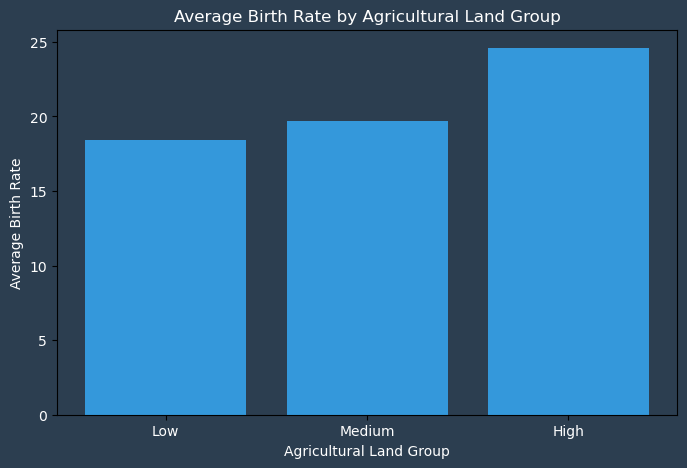

In [81]:
plt.figure(figsize=(8, 5))

plt.bar(
    birth_rate_by_agri.index,
    birth_rate_by_agri.values,
    color='#3498DB'
)

plt.title('Average Birth Rate by Agricultural Land Group',
          color='white')
plt.xlabel('Agricultural Land Group', color='white')
plt.ylabel('Average Birth Rate', color='white')

plt.xticks(color='white')
plt.yticks(color='white')
plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.show()

## 17. Relationship Analysis: Land Area vs Armed Forces

Compare land area and armed forces size using a scatter plot to look for a possible relationship between the two variables.

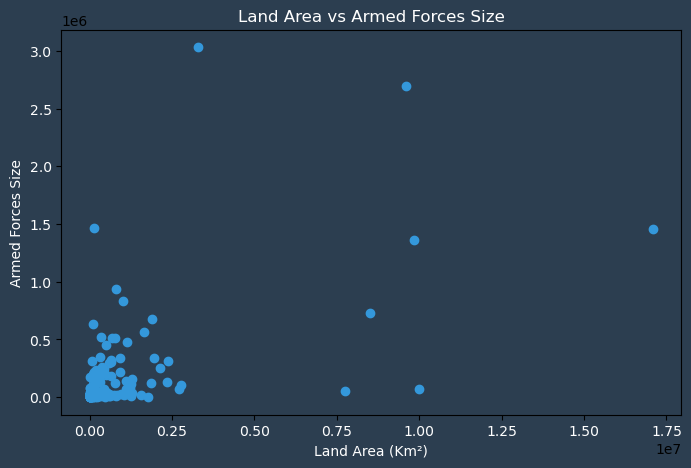

In [82]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Land Area(Km2)'],
    df['Armed Forces size'],
    color='#3498DB'
)

plt.title('Land Area vs Armed Forces Size', color='white')
plt.xlabel('Land Area (Km²)', color='white')
plt.ylabel('Armed Forces Size', color='white')

plt.xticks(color='white')
plt.yticks(color='white')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.show()

## 18. Percentile Analysis

Use NumPy percentiles to understand the distribution of country land areas.

- **25th percentile (Q1):** 25% of values are below this point
- **50th percentile (Q2):** median
- **75th percentile (Q3):** 75% of values are below this point

In [83]:
land_area = df['Land Area(Km2)'].to_numpy()

q1 = np.percentile(land_area, 25)
q2 = np.percentile(land_area, 50)
q3 = np.percentile(land_area, 75)

print("25th Percentile:", q1)
print("Median:", q2)
print("75th Percentile:", q3)

25th Percentile: 24456.5
Median: 119511.0
75th Percentile: 520544.0


In [84]:
large_countries = df[df['Land Area(Km2)'] >= q3]

large_countries[['Country', 'Land Area(Km2)']]

,Country,Land Area(Km2)
0,Afghanistan,652230.0
2,Algeria,2381741.0
4,Angola,1246700.0
6,Argentina,2780400.0
8,Australia,7741220.0
20,Bolivia,1098581.0
22,Botswana,581730.0
23,Brazil,8515770.0
32,Canada,9984670.0
33,Central African Republic,622984.0


## 19. Multi-Condition Filtering

Find countries that are above the dataset average in both:
- Birth rate
- Agricultural land percentage

Pandas uses `&` for an **AND** condition when filtering Series.

In [86]:
avg_birth_rate = df['Birth Rate'].mean()
avg_agri_land = df['Agricultural Land( %)'].mean()

avg_birth_rate, avg_agri_land

(20.145282051282052, 39.1348717948718)

In [88]:
high_birth_high_agri = df[
    (df['Birth Rate'] > avg_birth_rate) &
    (df['Agricultural Land( %)'] > avg_agri_land)
]

high_birth_high_agri[
    ['Country', 'Birth Rate', 'Agricultural Land( %)']
]

,Country,Birth Rate,Agricultural Land( %)
0,Afghanistan,32.49,58.1
4,Angola,40.73,47.5
22,Botswana,24.82,45.6
26,Burkina Faso,37.93,44.2
27,Burundi,39.01,79.2
28,Ivory Coast,35.74,64.8
34,Chad,42.17,39.7
38,Comoros,31.88,71.5
47,Djibouti,21.47,73.4
54,Eritrea,30.30,75.2


## 20. Check Text Data for Encoding Problems

Inspect country names for corrupted characters.

This is an important data-quality step because encoding problems can make country names difficult to read or affect matching/filtering operations.

In [89]:
df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'The Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Ivory Coast',
       'Cape Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Republic of the Congo', 'Costa Rica', 'Croatia',
       'Cuba', 'Cyprus', 'Czech Republic',
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'The Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada',
       'Guatemal

In [90]:
df.loc[
    df['Country'].str.contains('�', na=False),
    'Country'
] = 'São Tomé and Príncipe'

In [91]:
df[df['Country'] == 'São Tomé and Príncipe']

,Country,Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,Agricultural Land Group
150,São Tomé and Príncipe,ST,50.7,964.0,1000.0,31.54,239.0,S����,121.0,Medium


### Check All Text Columns

Check all object/text columns for the replacement character `�`.

This helps identify encoding problems in country names, abbreviations, or capital names.

In [92]:
text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    corrupted = df[df[column].astype(str).str.contains('�', na=False)]
    
    if len(corrupted) > 0:
        print(f"\n{column}:")
        print(corrupted[[column]])


Capital/Major City:
    Capital/Major City
23             Bras���
31             Yaound�
37              Bogot�
40       San Jos������
76           Reykjav��
104               Mal�
112            Chi����
136           Asunci��
150              S����
175               Lom�
176           Nuku����


## 21. Identify Corrupted Capital Names

Display the affected countries together with their capital names so that the incorrect values can be corrected accurately.

In [93]:
corrupted_capitals = df[
    df['Capital/Major City'].astype(str).str.contains('�', na=False)
]

corrupted_capitals[['Country', 'Capital/Major City']]

,Country,Capital/Major City
23,Brazil,Bras���
31,Cameroon,Yaound�
37,Colombia,Bogot�
40,Costa Rica,San Jos������
76,Iceland,Reykjav��
104,Maldives,Mal�
112,Moldova,Chi����
136,Paraguay,Asunci��
150,São Tomé and Príncipe,S����
175,Togo,Lom�


### Fix Corrupted Capital Names

Replace the corrupted capital names with their correct text values.

This ensures the final dataset is readable and suitable for presentation.

In [94]:
capital_fixes = {
    'Brazil': 'Brasília',
    'Cameroon': 'Yaoundé',
    'Colombia': 'Bogotá',
    'Costa Rica': 'San José',
    'Iceland': 'Reykjavík',
    'Maldives': 'Malé',
    'Moldova': 'Chișinău',
    'Paraguay': 'Asunción',
    'São Tomé and Príncipe': 'São Tomé',
    'Togo': 'Lomé',
    'Tonga': "Nuku'alofa"
}

for country, capital in capital_fixes.items():
    df.loc[df['Country'] == country, 'Capital/Major City'] = capital

In [95]:
for column in df.select_dtypes(include='object').columns:
    corrupted = df[df[column].astype(str).str.contains('�', na=False)]
    
    if len(corrupted) > 0:
        print(f"\n{column}:")
        print(corrupted[[column]])

## 22. Birth Rate Distribution

Use a boxplot to examine the median, spread, and possible outliers in birth rate.

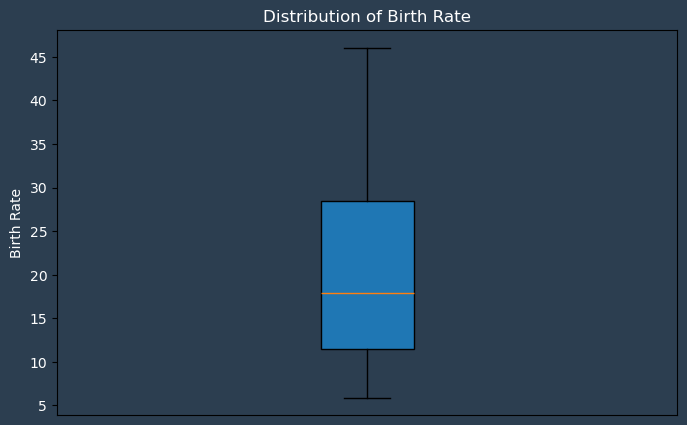

In [96]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df['Birth Rate'],
    patch_artist=True
)

plt.title('Distribution of Birth Rate', color='white')
plt.ylabel('Birth Rate', color='white')

plt.xticks([])
plt.yticks(color='white')

plt.gca().set_facecolor('#2C3E50')
plt.gcf().set_facecolor('#2C3E50')

plt.show()

## 23. Summary Statistics Table

Create one compact table containing the mean, median, minimum, and maximum for the main numerical indicators.

`Calling Code` is excluded because it is an identifier rather than a meaningful measurement.

In [98]:
summary = df[
    [
        'Agricultural Land( %)',
        'Land Area(Km2)',
        'Armed Forces size',
        'Birth Rate',
        'Co2-Emissions'
    ]
].agg(['mean', 'median', 'min', 'max']).round(2)

summary

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions
mean,39.13,686700.71,143487.18,20.15,171858.35
median,39.60,119511.00,31000.00,17.95,12303.00
min,0.60,0.00,0.00,5.90,11.00
max,82.60,17098240.00,3031000.00,46.08,9893038.00


## 24. Agricultural Land Group Distribution

Count how many countries belong to each agricultural-land group.

In [99]:
group_counts = df['Agricultural Land Group'].value_counts()

group_counts

Agricultural Land Group
Medium    93
Low       66
High      36
Name: count, dtype: int64

In [100]:
group_percent = df['Agricultural Land Group'].value_counts(normalize=True) * 100

group_percent.round(2)

Agricultural Land Group
Medium    47.69
Low       33.85
High      18.46
Name: proportion, dtype: float64

## 25. Countries with Zero Recorded Armed Forces

Filter countries where the dataset records an armed-forces size of zero.

**Note:** This describes the value recorded in the dataset; it should not automatically be treated as a definitive real-world conclusion.

In [101]:
no_armed_forces = df[
    df['Armed Forces size'] == 0
]

no_armed_forces[
    ['Country', 'Armed Forces size']
]

,Country,Armed Forces size
5,Antigua and Barbuda,0.0
72,Haiti,0.0
76,Iceland,0.0
97,Libya,0.0
154,Seychelles,0.0


In [102]:
len(no_armed_forces)

5

## 26. Create Birth Rate Groups

Divide countries into four birth-rate categories using `pd.cut()`:

- **Low:** 0–15
- **Moderate:** 15–25
- **High:** 25–35
- **Very High:** 35–50

In [103]:
df['Birth Rate Group'] = pd.cut(
    df['Birth Rate'],
    bins=[0, 15, 25, 35, 50],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

In [104]:
birth_rate_groups = df['Birth Rate Group'].value_counts().sort_index()

birth_rate_groups

Birth Rate Group
Low          77
Moderate     63
High         34
Very High    21
Name: count, dtype: int64

In [105]:
birth_rate_group_percent = (
    df['Birth Rate Group']
    .value_counts(normalize=True)
    .sort_index() * 100
)

birth_rate_group_percent.round(2)

Birth Rate Group
Low          39.49
Moderate     32.31
High         17.44
Very High    10.77
Name: proportion, dtype: float64

# Final Dataset Check

Confirm the final number of rows and columns after completing the analysis transformations.

In [106]:
df.shape

(195, 11)

In [107]:
df.columns

Index(['Country', 'Abbreviation', 'Agricultural Land( %)', 'Land Area(Km2)',
       'Armed Forces size', 'Birth Rate', 'Calling Code', 'Capital/Major City',
       'Co2-Emissions', 'Agricultural Land Group', 'Birth Rate Group'],
      dtype='object')

## 27. Prepare the Cleaned Dataset

The two group columns were created only for analysis, so remove them before saving the reusable cleaned dataset.

In [108]:
cleaned_df = df.drop(
    columns=['Agricultural Land Group', 'Birth Rate Group']
)

cleaned_df.to_csv(
    'global_country_analysis_cleaned.csv',
    index=False
)

In [109]:
cleaned_df.shape

(195, 9)

# Final Project Insights

Summarize the main numerical findings from the completed analysis.

In [111]:
print("GLOBAL COUNTRY ANALYSIS — KEY INSIGHTS")
print("-" * 50)

print(f"Total countries analyzed: {len(df)}")
print(f"Average birth rate: {df['Birth Rate'].mean():.2f}")
print(f"Median birth rate: {df['Birth Rate'].median():.2f}")
print(f"Average agricultural land: {df['Agricultural Land( %)'].mean():.2f}%")
print(f"Median land area: {df['Land Area(Km2)'].median():,.0f} Km²")

print("\nAgricultural Land Groups:")
print(group_percent.round(2))

print("\nBirth Rate Groups:")
print(birth_rate_group_percent.round(2))

print("\nCountries with no recorded armed forces:",
      len(no_armed_forces))

GLOBAL COUNTRY ANALYSIS — KEY INSIGHTS
--------------------------------------------------
Total countries analyzed: 195
Average birth rate: 20.15
Median birth rate: 17.95
Average agricultural land: 39.13%
Median land area: 119,511 Km²

Agricultural Land Groups:
Agricultural Land Group
Medium    47.69
Low       33.85
High      18.46
Name: proportion, dtype: float64

Birth Rate Groups:
Birth Rate Group
Low          39.49
Moderate     32.31
High         17.44
Very High    10.77
Name: proportion, dtype: float64

Countries with no recorded armed forces: 5


## 28. Identify Maximum Values

Use `idxmax()` with `loc[]` to find the country with the highest value for each major indicator.

In [113]:
max_values = {
    'Highest Agricultural Land ( %)': df.loc[
        df['Agricultural Land( %)'].idxmax(), 'Country'
    ],
    'Largest Land Area': df.loc[
        df['Land Area(Km2)'].idxmax(), 'Country'
    ],
    'Largest Armed Forces': df.loc[
        df['Armed Forces size'].idxmax(), 'Country'
    ],
    'Highest Birth Rate': df.loc[
        df['Birth Rate'].idxmax(), 'Country'
    ]
}

max_values

{'Highest Agricultural Land ( %)': 'Uruguay',
 'Largest Land Area': 'Russia',
 'Largest Armed Forces': 'India',
 'Highest Birth Rate': 'Niger'}

In [114]:
for label, country in max_values.items():
    print(label, ":", country)

Highest Agricultural Land ( %) : Uruguay
Largest Land Area : Russia
Largest Armed Forces : India
Highest Birth Rate : Niger


# Project Complete

The notebook now contains the complete workflow:

**Load → Inspect → Clean → Validate → Analyze → Visualize → Extract Insights → Save Cleaned Data**

The cleaned dataset is saved as `global_country_analysis_cleaned.csv`.